In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, dirichlet

 

 


def reflect(value, lower, upper):
    """Reflects a value within the given bounds [lower, upper]."""
    range_size = upper - lower
    while value < lower or value > upper:
        if value < lower:
            value = lower + (lower - value)  # Reflect off the lower bound
        elif value > upper:
            value = upper - (value - upper)  # Reflect off the upper bound
    return value

import numpy as np
from scipy.stats import beta

def sample_random_walk_beta_params(K, min_ab=0.7, max_ab=10.0, step_size=0.1, seed=None):
    """
    Generates K (a, b) pairs for Beta distributions using a random walk 
    with reflection to stay within bounds.

    Parameters:
        K : int
            Number of Beta distributions to sample.
        min_ab : float
            Minimum value for Beta parameters.
        max_ab : float
            Maximum value for Beta parameters.
        step_size : float
            Standard deviation of the random walk step (controls similarity).
        seed : int, optional
            Random seed for reproducibility.

    Returns:
        a_params, b_params : np.ndarray, np.ndarray
            Arrays of shape (K,) containing sampled Beta parameters.
    """
    rng = np.random.default_rng(seed)
    
    a_params = np.zeros(K)
    b_params = np.zeros(K)

    a_params[0] = rng.uniform(min_ab, max_ab)
    b_params[0] = rng.uniform(min_ab, max_ab)

    for i in range(1, K):
        a_new = a_params[i-1] + rng.normal(scale=step_size)
        b_new = b_params[i-1] + rng.normal(scale=step_size)

        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params
 
 


 


import numpy as np
from scipy.special import gamma

def beta_pdf(x, a, b):
    """
    Compute the Beta density at x given parameters a and b.
    
    Parameters:
        x : float or np.ndarray
            The point(s) at which to evaluate the density (should lie in [0,1]).
        a : float
            The first shape parameter.
        b : float
            The second shape parameter.
    
    Returns:
        float or np.ndarray: The beta density evaluated at x.
    """
    return (gamma(a + b) / (gamma(a) * gamma(b))) * (np.power(x, a - 1)) * (np.power(1 - x, b - 1))

 
 
import numpy as np
from scipy.stats import beta
 

def compute_conditional_and_marginal_density(x, a_params, b_params, U_levels, U_probs):
    """
    Computes the conditional density functions f(x|Z=z) for each group Z,
    and the overall marginal density f(x), for the model:
    
        X = Beta(a, b) + U,
    
    where U is a discrete confounder with levels U_levels and probabilities U_probs.
    
    For a given group with Beta parameters (a, b), the density at x is:
    
         f(x|Z=z) = sum_{u in U_levels} beta.pdf(x - u; a, b) * P(U=u)
    
    The marginal density is computed as the (equally weighted) average over groups.
    
    Parameters:
        x         : float or array_like
                    Points at which to evaluate the density.
        a_params  : array_like, shape (K,)
                    Group-level Beta distribution alpha parameters.
        b_params  : array_like, shape (K,)
                    Group-level Beta distribution beta parameters.
        U_levels  : array_like, shape (M,)
                    The discrete levels for U.
        U_probs   : array_like, shape (M,)
                    The probability mass for each U level (should sum to 1).
                    
    Returns:
        conditional_density : np.ndarray, shape (len(x), K)
            The conditional density f(x|Z=z) for each group z.
        marginal_density    : np.ndarray, shape (len(x),)
            The marginal density f(x), computed as the average over groups.
    """
    # Ensure x is a 1D array.
    x = np.atleast_1d(x)
    n = len(x)
    
    # Ensure a_params and b_params are arrays of shape (K,)
    a_params = np.atleast_1d(a_params)
    b_params = np.atleast_1d(b_params)
    K = len(a_params)
    
    # Convert U_levels and U_probs to arrays and ensure U_levels has shape (M,)
    U_levels = np.asarray(U_levels)
    U_probs = np.asarray(U_probs)
    M = len(U_levels)
    
    # Expand dimensions for vectorized evaluation:
    #   x_expanded: shape (n, 1, 1)
    #   U_expanded: shape (1, M, 1)
    #   a_params and b_params: shape (1, 1, K)
    x_expanded = x[:, None, None]
    U_expanded = U_levels[None, :, None]
    a_expanded = a_params[None, None, :]
    b_expanded = b_params[None, None, :]
    
    # Evaluate the Beta density at (x - u) for each combination of x, u, and group.
    # This returns an array of shape (n, M, K)
    pdf_vals = beta.pdf(x_expanded - U_expanded, a_expanded, b_expanded)
    
    # Incorporate the probability mass of each U level.
    # Reshape U_probs to (1, M, 1) so it broadcasts correctly.
    U_probs_expanded = U_probs[None, :, None]
    
    # Sum over the discrete U levels (axis=1) to get the conditional density for each group.
    # Resulting shape is (n, K)
    conditional_density = np.sum(pdf_vals * U_probs_expanded, axis=1)
    
    # Compute the marginal density as the average over groups.
    marginal_density = np.mean(conditional_density, axis=1)
    
    return conditional_density, marginal_density

import numpy as np
import matplotlib.pyplot as plt


def generate_basis_functions(epsilon=0.05, J=None, L=1):
    """
    Generates step function basis functions x -> 1(x > t) with knots in [0,1].
    If J is not provided, it is determined by ensuring an L-Lipschitz function 
    can be approximated within error epsilon.

    Parameters:
        epsilon : float, optional (default=0.05)
            The maximum allowable approximation error for an L-Lipschitz function.
        J : int, optional
            The number of basis functions (knots). If None, it is computed from epsilon.
        L : float, optional (default=1)
            The Lipschitz constant of the function to approximate.

    Returns:
        knots : np.array, shape (J,)
            The knot points in [0,1].
    """
    # Compute J if not given
    if J is None:
        J = max(1,int(np.ceil(L / (2 * epsilon))))

    # Create J equally spaced knot points in (0,1)
    knots = np.linspace(0, 1, J + 2)[:-1]  # Avoid endpoints 0 and 1    
 
    return knots

def construct_design_matrix(X, knots):
    """
    Constructs a design matrix for the step function basis on input X.

    Parameters:
        X : np.array, shape (N,)
            Input data points.
        knots : np.array, shape (J,)
            Knot points for the basis functions.

    Returns:
        design_matrix : np.array, shape (N, J)
            The design matrix where each column corresponds to 1(X > t_j).
    """
    return (X[:, None] > knots).astype(float)



import numpy as np

def discrete_gaussian(N, M, mu=0, sigma=0.1, lower=-1, upper=1, rng=None):
    """
    Samples N values from a discrete set of M evenly spaced points in [lower, upper],
    weighted according to a Gaussian distribution with mean mu and standard deviation sigma.
    
    Parameters:
      N (int): Number of samples to generate.
      M (int): Number of discrete levels in the interval.
      mu (float): Mean of the Gaussian weighting.
      sigma (float): Standard deviation of the Gaussian weighting.
      lower (float): Lower bound of the interval.
      upper (float): Upper bound of the interval.
      rng (np.random.Generator, optional): Numpy random number generator instance.
      
    Returns:
      np.ndarray: Array of N samples drawn from the discrete distribution.
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # Create M evenly spaced levels in [lower, upper]
    U_levels = np.linspace(lower, upper, M)
    
    # Compute unnormalized weights from the Gaussian density (ignoring the normalization constant)
    weights = np.exp(-0.5 * ((U_levels - mu) / sigma) ** 2)
    
    # Normalize weights to obtain probabilities
    probs = weights / np.sum(weights)
    
    # Sample N points from U_levels with the computed probabilities
    return rng.choice(U_levels, size=N, p=probs), U_levels, probs


import numpy as np
from scipy.stats import beta

 
def generate_data(K=1000, n=10, M=10, n_new=100_000, pZ_effect=0.1, range_ab=(0.75, 5), ab_new=None, step_size=0.1, delta=0.2, h_fun=None, seed_exps=None, seed_new = None, return_density=True):
    """
    Generates data based on the given simulation structure.

    Parameters:
        K         : int  - Number of groups (instrument levels, experiments).
        n         : int  - Number of samples per group.
        M         : int  - Number of levels for confounder U.
        range_ab  : tuple - Range for beta parameters (min, max).
        step_size : float - Step size for random walk beta parameter generation.
        delta     : float - Confounding effect parameter.
        h_fun     : function - Structural function for Y. Defaults to sin(6x).
        seed_exps : int - Random seed for generating a_params and b_params.

    Returns:
        dict : Keys {X, Y, Z, U, a_params, b_params, density_X_given_Z, h_fun}
               containing generated data and density function.
    """
    rng = np.random.default_rng()  # Fresh RNG instance for other random variables
    N = K * n  # Total sample size
    if h_fun is None:
        h_fun = lambda x: (6*x)  + np.sin(6 * x)

    # Generate U and Z
    sigma_U = 0.2
    U, U_levels, U_probs = discrete_gaussian(N=N, M=M, mu=0, sigma=sigma_U, lower=-0.5, upper=0.5, rng = rng)
    Z = np.repeat(np.arange(K), n)

    # Generate a_params and b_params with fixed seed
    a_params_effect, b_params_effect = sample_random_walk_beta_params(
        int(pZ_effect * K), min_ab=range_ab[0], max_ab=range_ab[1], step_size=step_size, seed=seed_exps
    )

    # Expand a_params and b_params
    repeats = K // len(a_params_effect)
    extra = K % len(a_params_effect)
    repeat_counts = np.full(len(a_params_effect), repeats)
    repeat_counts[:extra] += 1
    a_params = np.repeat(a_params_effect, repeat_counts)
    b_params = np.repeat(b_params_effect, repeat_counts)

    X = beta.rvs(a_params[Z], b_params[Z], random_state=rng) + U
    eps = rng.normal(0, 0.3, size=N)
    Y = h_fun(X) +   3 * U + eps

    #print(np.corrcoef(U, X)[0, 1])
    #print(np.corrcoef(U, Y)[0, 1])
    #print(np.array([np.corrcoef(Z == k, X)[0, 1] for k in range(K)]))
    #print(np.array([np.corrcoef(Z == k, Y)[0, 1] for k in range(K)]))

 

    # Generate new data
    U_new, U_levels_new, U_probs_new = discrete_gaussian(N=n_new, M=M, mu=0, sigma=sigma_U, lower=-0.5, upper=0.5, rng = rng)
    if ab_new is None:
        a_param_new, b_param_new = sample_random_walk_beta_params(1, range_ab[0], range_ab[1], step_size, seed_new)
    else:
        a_param_new, b_param_new = ab_new
    X_new = beta.rvs(a_param_new, b_param_new,  size=n_new, random_state=rng) + U_new


    density_new = lambda x: compute_conditional_and_marginal_density(x, a_param_new, b_param_new, U_levels_new, U_probs_new)[0]


    #print(np.corrcoef(U_new, X_new)[0, 1])
    #print(np.corrcoef(U_new, Y_new)[0, 1])
    
    #print(np.corrcoef(U_new, h_fun(X_new))[0, 1])
 
    
    if return_density:
        density_X_given_Z = lambda x: compute_conditional_and_marginal_density(x, a_params, b_params, U_levels, U_probs)[0]
    else:
        density_X_given_Z = None

    return {
        "X": X,
        "Y": Y,
        "Z": Z,
        "U": U,
        "eps": eps,
        "X_new": X_new,
        "a_params": a_params,
        "b_params": b_params,
        "density_X_given_Z": density_X_given_Z,
        "density_new": density_new,
        "h_fun": h_fun,
        "K": K,
        "M": M,
        "delta": delta
    }







In [2]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.utils import *
from discreteNPIV.solve_primal_structural import *

# settings
freq = 3.14
h_fun = lambda x: x 
L = 3  # Lipschitz constant
n = 100
K = 1000
M = 10
step_size = 0.2


# Generate synthetic data for model fitting and evaluation
data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1)
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)


# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=L)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)




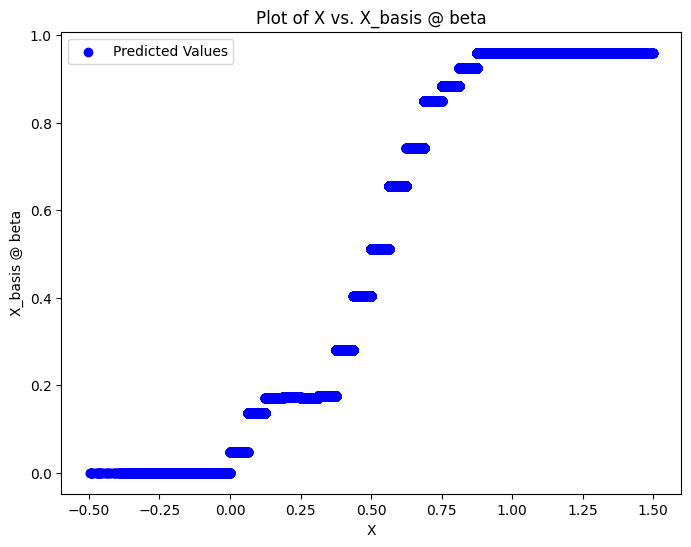

In [3]:
import numpy as np
import matplotlib.pyplot as plt

lambda_K = 1e-3
gamma = 1e-3
beta = solve_primal_structural(X_basis, Z, Y, lambda_K = lambda_K, gamma = gamma)


# Assuming X, X_basis, and beta are already defined
predicted_values = X_basis @ beta

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X, predicted_values, label='Predicted Values', color='blue')
plt.title('Plot of X vs. X_basis @ beta')
plt.xlabel('X')
plt.ylabel('X_basis @ beta')
plt.legend()
plt.show()

In [4]:
out_jive, out_2sls, use_npjive = cross_validate_primal(X_basis,Z,Y)
 

time to tune primal:  0.09042787551879883 , time to cv split:  0.8077731132507324


time to tune primal:  0.09037399291992188 , time to cv split:  0.8045659065246582


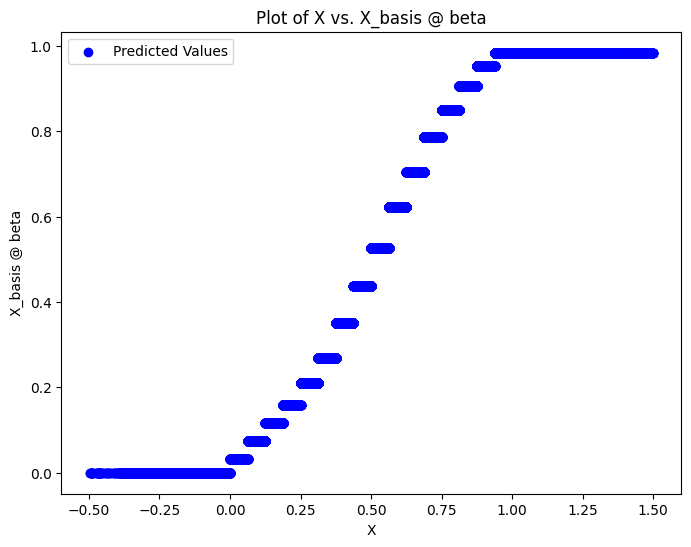

In [5]:
import numpy as np
import matplotlib.pyplot as plt

lambda_K = out_jive['lambda']
gamma = out_jive['gamma']
beta = solve_primal_structural(X_basis, Z, Y, lambda_K = lambda_K, gamma = gamma)


beta, fit_info = npiv_structural(X_basis, Z, Y)

                    
# Assuming X, X_basis, and beta are already defined
predicted_values = X_basis @ beta

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X, predicted_values, label='Predicted Values', color='blue')
plt.title('Plot of X vs. X_basis @ beta')
plt.xlabel('X')
plt.ylabel('X_basis @ beta')
plt.legend()
plt.show()